In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import pandas as pd
import awkward as ak
import tensorflow as tf
from tensorflow import keras
import matplotlib
#matplotlib.use("Agg")
matplotlib.rcParams["figure.figsize"] = [6.4 / 1.3, 4.8 / 1.3]
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from argparse import ArgumentParser
import mplhep as hep
import vector
import hist
from hist import Hist
from general import custom_objects, feat, table_to_numpy_visualization, load_normalization, SwitchLayer, HDF5File, MaxPassLayer, TitledModel
from model_bcls import make_model as make_model_b
from model_bcls import load_data as load_data_b
from model_tt import make_model, load_data as load_data_tt

In [4]:
a = 50 # Regulates the ratio between dark matter and SM events

In [5]:
def get_normalization(table, exclude=None):
    offset = table.nanmean()
    scale =  table.nanstd()
    
    print(offset)
    print(scale)
    
    for column in ak.fields(offset):
        if exclude is not None and column in exclude:
            offset[column] = [0.0]
            scale[column] = [1.0]
        if scale[column][0] == 0:  # Avoid NaN after divison
            scale[column] = [1.0]
    return offset, scale

## Main

loading all possible datasets

In [8]:
def load_dataset(path):
    with HDF5File(path, "r") as f:
        data   = f["data"]
        offset = f["offset"]
        scale  = f["scale"]
        for field in data.fields:
            data[field] = data[field] * scale[field] + offset[field]
        return data

In [10]:
path         = "/nfs/dust/cms/user/stafford/For_Emanuele/reconn/1308_nn_lim_ins/"
lighter_path = "/nfs/dust/cms/user/stafford/For_Emanuele/reconn/2008_lighter_ttbar/"
train_datasets = [path + f"_TTbarDMJets_Dilepton_scalar_LO_Mchi_1_Mphi_{i*50}_TuneCP5_13TeV_madgraph_mcatnlo_pythia8/traindata.hdf5" for i in range(4,5)]
train_datasets = train_datasets + [lighter_path + "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8/traindata.hdf5"]

valid_datasets = [path + f"_TTbarDMJets_Dilepton_scalar_LO_Mchi_1_Mphi_{i*50}_TuneCP5_13TeV_madgraph_mcatnlo_pythia8/validatedata.hdf5" for i in range(4,5)]
valid_datasets = valid_datasets + [lighter_path + "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8/validatedata.hdf5"]


In [12]:
train_data_list = [load_dataset(dataset) for dataset in train_datasets]   
train_weights = [data['weight'] for data in train_data_list]

valid_data_list = [load_dataset(dataset) for dataset in valid_datasets]
valid_weights = [data['weight'] for data in valid_data_list]

50 39.564400000679406 36114 3.0335656397206986e-08


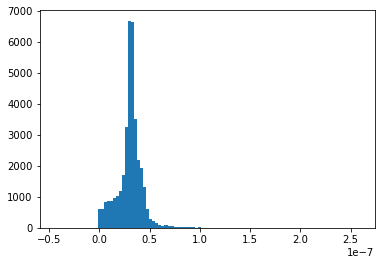

SM 266577.0848442487 957636 2.9068450787123273e-07


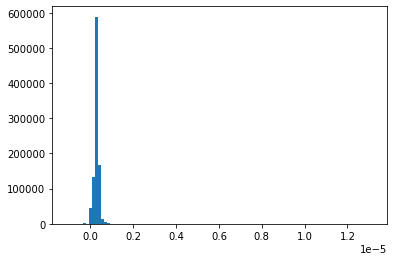

39.564400000679406 266616.6492442494


In [13]:
for i, weight in enumerate(train_weights):
    if i < len(train_weights)-1:
        print((i+1)*50, sum(weight), len(weight), np.mean(weight/len(weight)))
    else:
        print('SM', sum(weight), len(weight), np.mean(weight/len(weight)))
    plt.hist(weight/len(weight), bins=100)
    plt.show()

tot_DM_train = sum([sum(w) for w in train_weights[:-1]])
tot_SM_train = sum(train_weights[-1])
tot_train = tot_DM_train + tot_SM_train

tot_DM_valid = sum([sum(w) for w in valid_weights[:-1]])
tot_SM_valid = sum(valid_weights[-1])
tot_valid = tot_DM_valid + tot_SM_valid

print(tot_DM_train, tot_train)

In [14]:
# Normalize each DM dataset and the SM dataset
DM_sums_train = [sum(w) for w in train_weights]
for i in range(len(train_weights)-1):
    train_weights[i] = train_weights[i] / DM_sums_train[i]
train_weights[-1] = train_weights[-1] / sum(train_weights[-1])

tot_DM_train = sum([sum(w) for w in train_weights[:-1]])
tot_SM_train = sum(train_weights[-1])
tot_train = tot_DM_train + tot_SM_train

print(tot_DM_train, tot_train)

'''
DM_sums_valid = [sum(w) for w in valid_weights[:-1]]
for i in range(10):
    valid_weights[i] = valid_weights[i] / DM_sums_valid[i]
valid_weights[-1] = valid_weights[-1] / sum(valid_weights[-1])
'''
for i in range(len(train_weights)-1):
    valid_weights[i] = valid_weights[i] / DM_sums_train[i]
valid_weights[-1] = valid_weights[-1] / DM_sums_train[-1]

tot_DM_valid = sum([sum(w) for w in valid_weights[:-1]])
tot_SM_valid = sum(valid_weights[-1])
tot_valid = tot_DM_valid + tot_SM_valid

1.000000000000006 1.9999999999999947


In [15]:
reweight_factor_DM = (a / 100) * 1.
reweight_factor_SM = ((100 - a) / 100)

check_sum = 0
for i in range(len(train_weights)-1):
    train_data_list[i]["montecarlo_weight"] = train_data_list[i]["weight"]
    train_data_list[i]["weight"] = train_weights[i] * reweight_factor_DM
    check_sum+=sum(train_data_list[i]['weight'])
train_data_list[-1]["montecarlo_weight"] = train_data_list[-1]["weight"]
train_data_list[-1]["weight"] = train_weights[-1] * reweight_factor_SM

check_sum+=sum(train_data_list[-1]['weight'])
print(check_sum, sum(train_data_list[-1]['weight']))

check_sum_valid = 0

for i in range(len(train_weights)-1):
    valid_data_list[i]["montecarlo_weight"] = valid_data_list[i]["weight"]
    valid_data_list[i]["weight"] = valid_weights[i] * reweight_factor_DM
    check_sum_valid+=sum(valid_data_list[i]['weight'])
valid_data_list[-1]["montecarlo_weight"] = valid_data_list[-1]["weight"]
valid_data_list[-1]["weight"] = valid_weights[-1] * reweight_factor_SM

check_sum_valid+=sum(valid_data_list[-1]['weight'])
print(check_sum_valid, sum(valid_data_list[-1]['weight']))

0.9999999999999973 0.4999999999999943
0.4299449889838031 0.21431870449225912


In [16]:
missing_fields = ['gendmmed_t', 'gendmmed_x', 'gendmmed_y', 'gendmmed_z']
sm_length_train = len(train_data_list[-1]['weight'])
sm_length_valid = len(valid_data_list[-1]['weight'])

for field in missing_fields:
    train_data_list[-1][field] = np.full(sm_length_train, 0)
    valid_data_list[-1][field] = np.full(sm_length_valid, 0)


In [17]:
'''
for i in range(10):
    train_data_list[i]["mediator_mass"] = np.full(len(train_data_list[i]["weight"]), (i+1) * 50)
    valid_data_list[i]["mediator_mass"] = np.full(len(valid_data_list[i]["weight"]), (i+1) * 50)
train_data_list[-1]["mediator_mass"] = np.full(sm_length_train, np.nan)
valid_data_list[-1]["mediator_mass"] = np.full(sm_length_valid, np.nan)
'''

'\nfor i in range(10):\n    train_data_list[i]["mediator_mass"] = np.full(len(train_data_list[i]["weight"]), (i+1) * 50)\n    valid_data_list[i]["mediator_mass"] = np.full(len(valid_data_list[i]["weight"]), (i+1) * 50)\ntrain_data_list[-1]["mediator_mass"] = np.full(sm_length_train, np.nan)\nvalid_data_list[-1]["mediator_mass"] = np.full(sm_length_valid, np.nan)\n'

In [ ]:
fields_train = train_data_list[0].fields
combined_train_data = {field: ak.concatenate([data[field] for data in train_data_list]) for field in fields_train}

fields_valid = valid_data_list[0].fields
combined_valid_data = {field: ak.concatenate([data[field] for data in valid_data_list]) for field in fields_valid}

In [ ]:
combined_train_data

In [ ]:
train_shuffled_indices = np.random.permutation(len(combined_train_data["weight"]))
shuffled_train_data =  ak.Array({key: combined_train_data[key][train_shuffled_indices] for key in combined_train_data})
shuffled_train_data = ak.with_name(shuffled_train_data, "Dataframe")

In [ ]:
valid_shuffled_indices = np.random.permutation(len(combined_valid_data["weight"]))
shuffled_valid_data =  ak.Array({key: combined_valid_data[key][valid_shuffled_indices] for key in combined_valid_data})
shuffled_valid_data = ak.with_name(shuffled_valid_data, "Dataframe")

In [ ]:
exclude_fields = ["source", "weight", "jet_flav"]
train_offset, train_scale = get_normalization(shuffled_train_data, exclude=exclude_fields)

normalized_train_data = (shuffled_train_data - train_offset) / train_scale

In [ ]:
valid_offset, valid_scale = get_normalization(shuffled_valid_data, exclude=exclude_fields)

#normalized_valid_data = (shuffled_valid_data - valid_offset) / valid_scale
normalized_valid_data = (shuffled_valid_data - train_offset) / train_scale

In [ ]:
# Save combined dataset
combined_path = f"/nfs/dust/cms/user/coradine/DATA_SPECIAL_DM_SM_100/DM_{int(a)}_SM_{int(100-a)}/traindata.hdf5"

directory = os.path.dirname(combined_path)

# Create the directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)
    
with HDF5File(combined_path, "w") as f:
    # Save the combined normalized data
    f["data"] = normalized_train_data

    # Save the offset and scale
    f["offset"] = train_offset
    f["scale"] = train_scale

print(f"Combined dataset saved to {combined_path}")

In [ ]:
combined_valid_path = f"/nfs/dust/cms/user/coradine/DATA_SPECIAL_DM_SM_100/DM_{int(a)}_SM_{int(100-a)}/validatedata.hdf5"
with HDF5File(combined_valid_path, "w") as f:
    # Save the combined normalized data
    f["data"] = normalized_valid_data

    # Save the offset and scale
    #f["offset"] = valid_offset
    #f["scale"] = valid_scale
    f["offset"] = train_offset
    f["scale"] = train_scale
print(f"Combined validation dataset saved to {combined_valid_path}")
